### Churn Prediction with KNN
Author: Marc Tanguy
Description: Predict whether a type of costumer is going to churn using KNN

#### Step 1: Load and explore the data

In [1]:
import pandas as pd

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print(df.shape)
print(df.head())
print(df.dtypes)

df['Churn'].value_counts(normalize=True)


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64

In [2]:
# Target balance
print("=== Churn Balance ===")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True).round(2))

# Contract type
print("\n=== Contract Type ===")
print(df['Contract'].value_counts())

# Tenure distribution (numeric, so we bin it)
print("\n=== Tenure Groups ===")
df['tenure_group'] = pd.cut(df['tenure'], bins=[0, 12, 24, 48, 72], labels=['0-12m', '13-24m', '25-48m', '49-72m'])
print(df['tenure_group'].value_counts().sort_index())

# Monthly Charges
print("\n=== Monthly Charges ===")
print(df['MonthlyCharges'].describe().round(2))

# Total Charges - note that this column is object type, so we need to convert it to numeric first
print("\n=== Total Charges ===")
print(df['TotalCharges'].apply(pd.to_numeric, errors='coerce').describe().round(2))

=== Churn Balance ===
Churn
No     5174
Yes    1869
Name: count, dtype: int64
Churn
No     0.73
Yes    0.27
Name: proportion, dtype: float64

=== Contract Type ===
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

=== Tenure Groups ===
tenure_group
0-12m     2175
13-24m    1024
25-48m    1594
49-72m    2239
Name: count, dtype: int64

=== Monthly Charges ===
count    7043.00
mean       64.76
std        30.09
min        18.25
25%        35.50
50%        70.35
75%        89.85
max       118.75
Name: MonthlyCharges, dtype: float64

=== Total Charges ===
count    7032.00
mean     2283.30
std      2266.77
min        18.80
25%       401.45
50%      1397.48
75%      3794.74
max      8684.80
Name: TotalCharges, dtype: float64


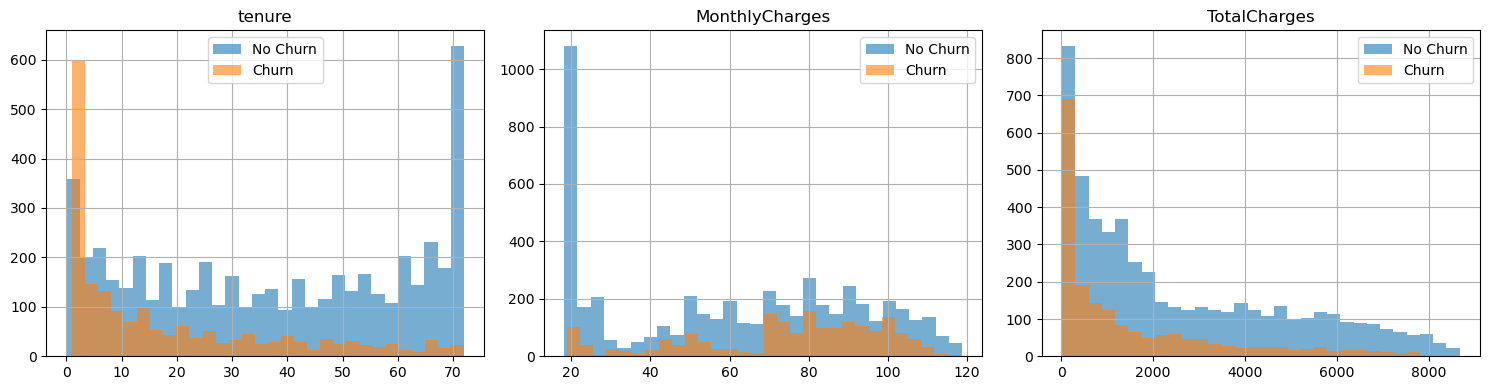

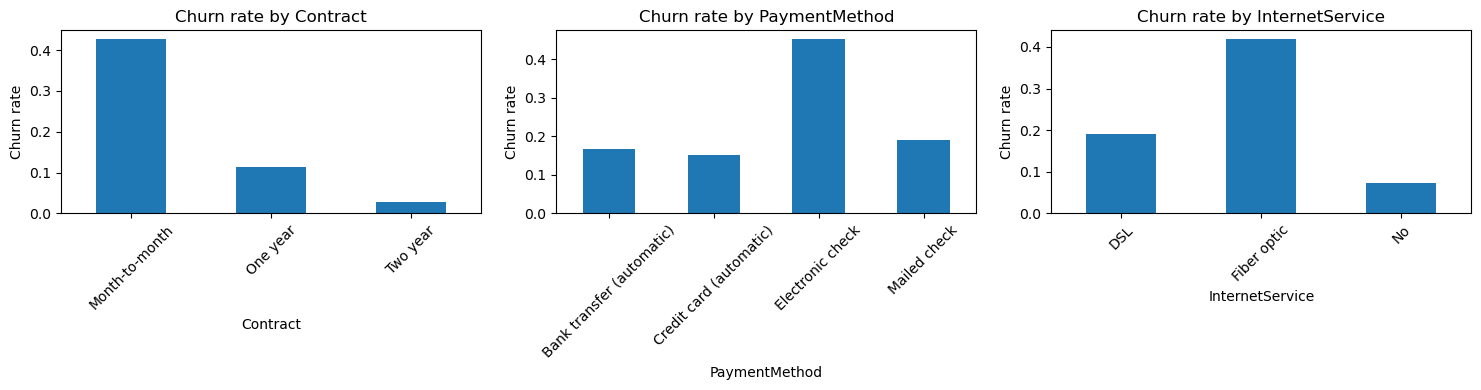

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
df_raw['TotalCharges'] = pd.to_numeric(df_raw['TotalCharges'], errors='coerce')
df_raw['Churn'] = df_raw['Churn'].map({'Yes': 1, 'No': 0})  # needed to calculate mean

# Numeric features
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(numeric_cols):
    df_raw[df_raw['Churn'] == 0][col].hist(alpha=0.6, ax=axes[i], bins=30, label='No Churn')
    df_raw[df_raw['Churn'] == 1][col].hist(alpha=0.6, ax=axes[i], bins=30, label='Churn')
    axes[i].set_title(col)
    axes[i].legend()
plt.tight_layout()
plt.show()

# Categorical features
cat_cols = ['Contract', 'PaymentMethod', 'InternetService']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for i, col in enumerate(cat_cols):
    df_raw.groupby(col)['Churn'].mean().plot(kind='bar', ax=axes[i])
    axes[i].set_title(f'Churn rate by {col}')
    axes[i].set_ylabel('Churn rate')
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Step 2: Data preprocessing

In [5]:
# Missing values per column
print(df.isnull().sum())
print(df.isnull().mean().round(2))

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges         0
Churn                0
tenure_group        11
dtype: int64
customerID          0.0
gender              0.0
SeniorCitizen       0.0
Partner             0.0
Dependents          0.0
tenure              0.0
PhoneService        0.0
MultipleLines       0.0
InternetService     0.0
OnlineSecurity      0.0
OnlineBackup        0.0
DeviceProtection    0.0
TechSupport         0.0
StreamingTV         0.0
StreamingMovies     0.0
Contract            0.0
PaperlessBilling    0.0
PaymentMethod       0.0
MonthlyCharges      0.0
TotalCharges        0.0
C

In [6]:
# 1. Fix TotalCharges (coerce blanks to NaN)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill TotalCharges NaNs with median (only 11 rows affected)
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].median())

# 2. Drop customerID (not useful for modeling) - other columns are all relevant for modeling, so we keep them
df.drop(columns=['customerID'], inplace=True)

# Drop the tenure_group we created earlier (it was just for EDA)
if 'tenure_group' in df.columns:
    df.drop(columns=['tenure_group'], inplace=True)

# 3. Encode target variable / convert target to binary
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# 4. Binary columns — map Yes/No to 1/0
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

# Gender
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

# One-hot encode multi-category columns
cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
            'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
            'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# 5. Separate features (X) from target (y)
X = df.drop(columns=['Churn'])
y = df['Churn']

print(X.shape)
print(y.value_counts())


(7043, 30)
Churn
0    5174
1    1869
Name: count, dtype: int64


#### Step 3: Split the data

In [7]:
from sklearn.model_selection import train_test_split

# Split into train and test sets (80% train, 20% test), stratified to maintain churn ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train set shape:", X_train.shape)
print("Test set shape:", X_test.shape)
print("Train set churn distribution:")
print(y_train.value_counts(normalize=True).round(2))
print("Test set churn distribution:")
print(y_test.value_counts(normalize=True).round(2))

Train set shape: (5634, 30)
Test set shape: (1409, 30)
Train set churn distribution:
Churn
0    0.73
1    0.27
Name: proportion, dtype: float64
Test set churn distribution:
Churn
0    0.73
1    0.27
Name: proportion, dtype: float64


#### Step 4: Train a KKK Model 

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Scale features — required for KNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Initialize and train the model
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


#### Step 5: Make Predictions and Evaluate

In [9]:
# Make predictions on the test set
y_pred = knn.predict(X_test_scaled)

# Calculate accuracy, precision, and recall
from sklearn.metrics import accuracy_score, precision_score, recall_score

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))

# Confusion matrix
from sklearn.metrics import confusion_matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# Classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7473385379701917
Precision: 0.5252808988764045
Recall: 0.5

Confusion Matrix:
[[866 169]
 [187 187]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.84      0.83      1035
           1       0.53      0.50      0.51       374

    accuracy                           0.75      1409
   macro avg       0.67      0.67      0.67      1409
weighted avg       0.74      0.75      0.75      1409



As the model has more non-churn data to train from, it is actually not very good at predicting churn. Only around 50% recall (catching costumers who actually churn). We cannot really trust it as it is.

#### Step 6: Experiment and Improve

In [10]:

# Try different K values and store results
k_values = [1, 3, 5, 7, 9, 11, 15]
results = []

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_scaled, y_train)
    y_pred_k = knn_k.predict(X_test_scaled)
    
    results.append({
        'K': k,
        'Accuracy': accuracy_score(y_test, y_pred_k),
        'Precision': precision_score(y_test, y_pred_k),
        'Recall': recall_score(y_test, y_pred_k),
    })

# Display as a DataFrame for easy comparison
results_df = pd.DataFrame(results)
print(results_df)

# Find best K by recall (most important for churn)
best_k = results_df.loc[results_df['Recall'].idxmax(), 'K']
print(f"\nBest K by Recall: {best_k}")

    K  Accuracy  Precision    Recall
0   1  0.716111   0.466667  0.486631
1   3  0.743790   0.517711  0.508021
2   5  0.747339   0.525281  0.500000
3   7  0.759404   0.549858  0.516043
4   9  0.770050   0.569444  0.548128
5  11  0.773598   0.577031  0.550802
6  15  0.770050   0.570621  0.540107

Best K by Recall: 11


The K value 11 is the better fit for the purpose, getting closer to 60% recall. However this is still not satisfying for our purposes as catching only 60% of costumers who churn wouldn't be the most effective result.

#### Step 7: Analysis and Recommendations

The model's accuracy is around 75% but this isn't something that we need to take into account for efficiency in this case because of the class imbalance. In this case the most relevant metric is recall on churn and the results aren't very satisfying.

Although the KNN model does not provide importance scores, after the above generated charts in Step 2 we can see that Tenure is the main imprtant feature, clearly showing that long-tenure costumers almost never churn. Then Contract type, month-to-month contracts have a higher churn rate as it would be predictable, also electronic payment methods, which indicate both less-engaged or more flexible costumers when changing provider.

##### Business recommendations
Target retention efforts at the highest-risk segment: month-to-month contracts, less than 12 months tenure, high monthly charges. These customers are easy to identify. Specific actions could be: outreaching at the 3 and 6 month marks, incentives to switch to annual contracts, and personalized pricing reviews for high-charge customers showing early churn signals. Maybe also offers in terms of internet service as we see that fiber optic costumers are more likely to churn, maybe dissatisfied with value for money or service quality.

##### Model imitations
Recall of 0.50 on churners means we're missing half — not reliable enough / KNN has no built-in feature importance so we can't easily explain predictions to stakeholders / The model has no mechanism to handle class imbalance, which is the root cause of the weak churn recall / The dataset is static — a real churn model needs to be retrained regularly as customer behavior shifts over time